
# India Tech Job Market Analysis
## Step 6 — Data Analyst Career Analysis

### Objective
Analyze the job market specifically for **Data Analyst** roles.

This section answers:
- How many Data Analyst postings are present?
- Which experience levels have the most Data Analyst openings?
- What are the common work modes and job types?
- Which cities have Data Analyst opportunities?
- What skills are most frequently requested?
- What is the salary by experience level?
- What is the competition for Data Analyst postings?
- Which industries and companies have Data Analyst opportunities?
- What education requirements appear most often?

**Important:** These findings describe this dataset only. They should not be presented as a complete representation of the Indian Data Analyst job market.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Load the cleaned dataset
df = pd.read_csv(Path("india_job_market_2024_2026_cleaned.csv"))

# Filter Data Analyst roles
da = df[
    df["Job_Title"].str.strip().str.lower() == "data analyst"
].copy()

print("Total records in dataset:", len(df))
print("Data Analyst postings:", len(da))
print("Data Analyst share: {:.2f}%".format(len(da) / len(df) * 100))


Total records in dataset: 5000
Data Analyst postings: 254
Data Analyst share: 5.08%


## 1. Data Analyst Job Profile Overview

In [2]:

overview = pd.DataFrame({
    "Metric": [
        "Data Analyst Job Postings",
        "Total Openings",
        "Average Salary (LPA)",
        "Median Salary (LPA)",
        "Average Applicants",
        "Average Applicants per Opening",
        "Average Skills per Job"
    ],
    "Value": [
        len(da),
        da["Openings"].sum(),
        round(da["Salary_LPA"].mean(), 2),
        round(da["Salary_LPA"].median(), 2),
        round(da["Applicants"].mean(), 2),
        round(da["Applicants_per_Opening"].mean(), 2),
        round(da["Skill_Count"].mean(), 2)
    ]
})

display(overview)


,Metric,Value
0,Data Analyst Job Postings,254.00
1,Total Openings,931.00
2,Average Salary (LPA),20.59
3,Median Salary (LPA),15.55
4,Average Applicants,296.89
5,Average Applicants per Opening,83.90
6,Average Skills per Job,4.50


## 2. Data Analyst Jobs by Experience Level

,Experience_Level,Job_Postings
0,Mid (3-6 yrs),82
1,Junior (1-3 yrs),48
2,Fresher (0-1 yr),46
3,Senior (6-10 yrs),46
4,Lead (10+ yrs),32


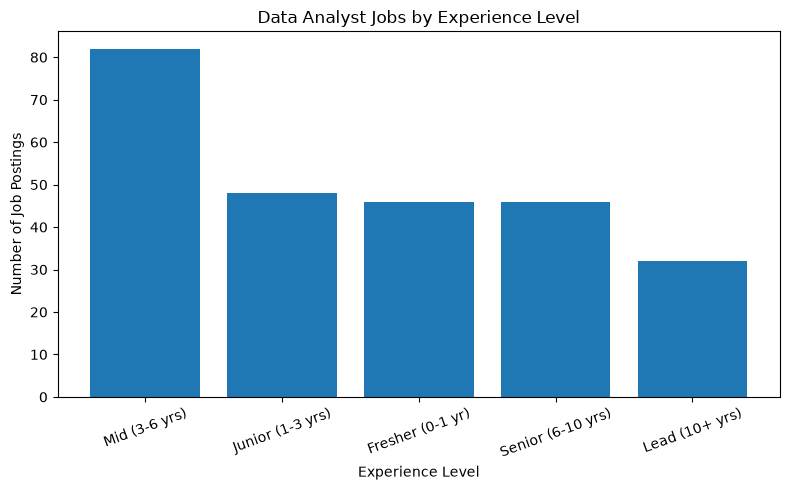

In [3]:

da_experience = (
    da["Experience_Level"]
    .value_counts()
    .rename_axis("Experience_Level")
    .reset_index(name="Job_Postings")
)

display(da_experience)

plt.figure(figsize=(8, 5))
plt.bar(
    da_experience["Experience_Level"],
    da_experience["Job_Postings"]
)
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")
plt.title("Data Analyst Jobs by Experience Level")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 3. Salary by Data Analyst Experience Level

,Experience_Level,Job_Postings,Average_Salary_LPA,Median_Salary_LPA
2,Lead (10+ yrs),32,50.850000,56.95
4,Senior (6-10 yrs),46,32.380435,36.00
3,Mid (3-6 yrs),82,16.780488,18.80
1,Junior (1-3 yrs),48,10.143750,10.15
0,Fresher (0-1 yr),46,5.432609,5.35


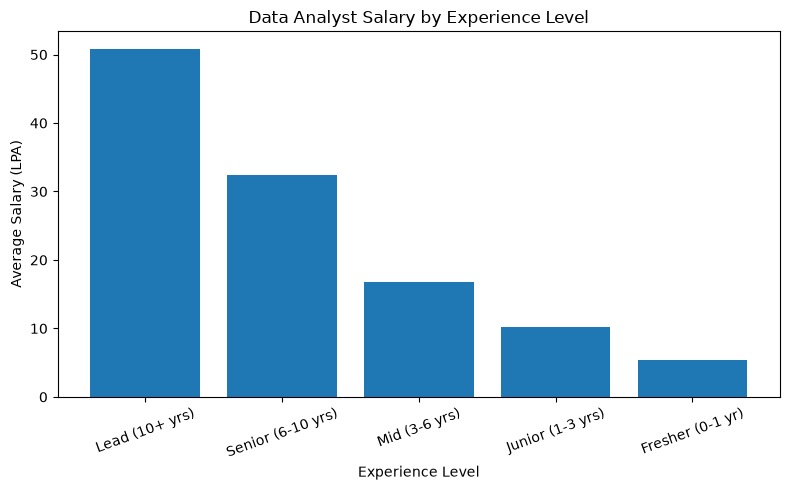

In [4]:

da_salary_experience = (
    da.groupby("Experience_Level")
    .agg(
        Job_Postings=("Job_ID", "count"),
        Average_Salary_LPA=("Salary_LPA", "mean"),
        Median_Salary_LPA=("Salary_LPA", "median")
    )
    .reset_index()
    .sort_values("Average_Salary_LPA", ascending=False)
)

display(da_salary_experience)

plt.figure(figsize=(8, 5))
plt.bar(
    da_salary_experience["Experience_Level"],
    da_salary_experience["Average_Salary_LPA"]
)
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (LPA)")
plt.title("Data Analyst Salary by Experience Level")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Data Analyst Jobs by Work Mode

,Work_Mode,Job_Postings
0,On-Site,108
1,Hybrid,81
2,Remote,65


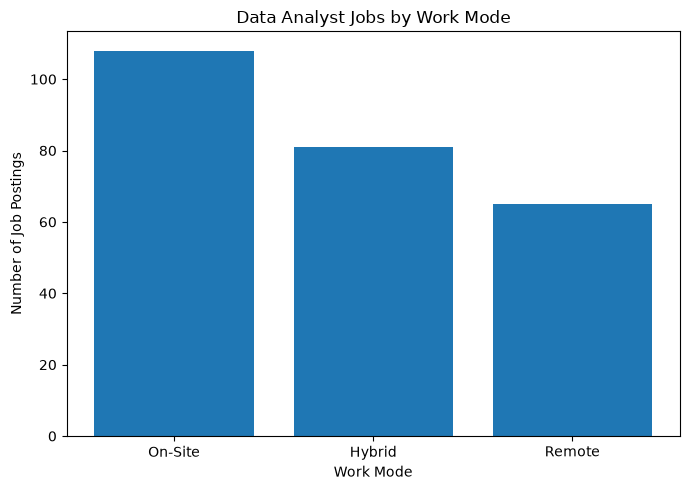

In [5]:

da_work_mode = (
    da["Work_Mode"]
    .value_counts()
    .rename_axis("Work_Mode")
    .reset_index(name="Job_Postings")
)

display(da_work_mode)

plt.figure(figsize=(7, 5))
plt.bar(
    da_work_mode["Work_Mode"],
    da_work_mode["Job_Postings"]
)
plt.xlabel("Work Mode")
plt.ylabel("Number of Job Postings")
plt.title("Data Analyst Jobs by Work Mode")
plt.tight_layout()
plt.show()


## 5. Data Analyst Jobs by Job Type

,Job_Type,Job_Postings
0,Full-Time,190
1,Contract,27
2,Internship,26
3,Part-Time,11


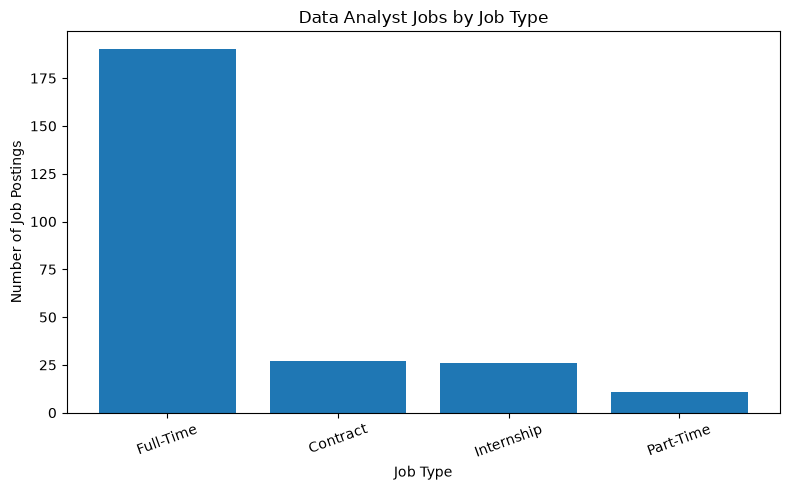

In [6]:

da_job_type = (
    da["Job_Type"]
    .value_counts()
    .rename_axis("Job_Type")
    .reset_index(name="Job_Postings")
)

display(da_job_type)

plt.figure(figsize=(8, 5))
plt.bar(
    da_job_type["Job_Type"],
    da_job_type["Job_Postings"]
)
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.title("Data Analyst Jobs by Job Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 6. Data Analyst Opportunities by City

,City,Job_Postings
0,Remote,101
1,Pune,23
2,Hyderabad,21
3,Mumbai,19
4,Delhi,17
5,Bangalore,13
6,Chennai,12
7,Bhubaneswar,7
8,Kochi,7
9,Kolkata,6


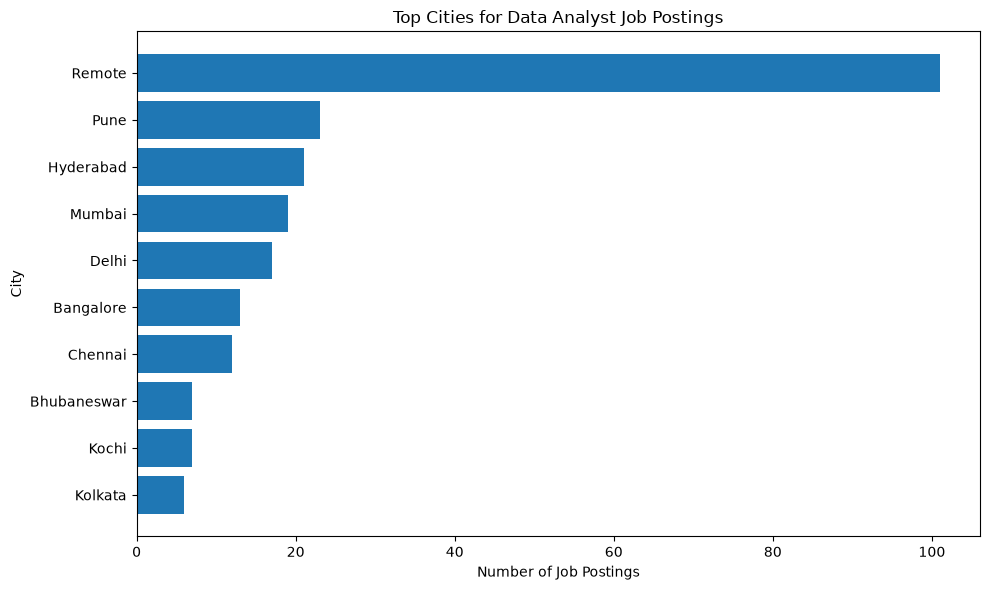

In [7]:

da_city = (
    da["City"]
    .value_counts()
    .rename_axis("City")
    .reset_index(name="Job_Postings")
)

display(da_city.head(15))

top_da_cities = da_city.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_da_cities["City"][::-1],
    top_da_cities["Job_Postings"][::-1]
)
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.title("Top Cities for Data Analyst Job Postings")
plt.tight_layout()
plt.show()


## 7. Data Analyst Skills

In [8]:

da_skill_counter = Counter()

for skills in da["Skills_Required"].dropna():
    skill_list = [
        s.strip() for s in str(skills).split(",")
        if s.strip()
    ]
    da_skill_counter.update(skill_list)

da_skills = pd.DataFrame(
    da_skill_counter.most_common(),
    columns=["Skill", "Job_Postings"]
)

# Calculate percentage of Data Analyst postings containing each skill
da_skills["Percentage_of_DA_Jobs"] = (
    da_skills["Job_Postings"] / len(da) * 100
).round(2)

display(da_skills.head(20))


,Skill,Job_Postings,Percentage_of_DA_Jobs
0,Data Visualization,178,70.08
1,Power BI,171,67.32
2,Statistics,169,66.54
3,SQL,168,66.14
4,Tableau,160,62.99
5,Excel,155,61.02
6,Python,143,56.30


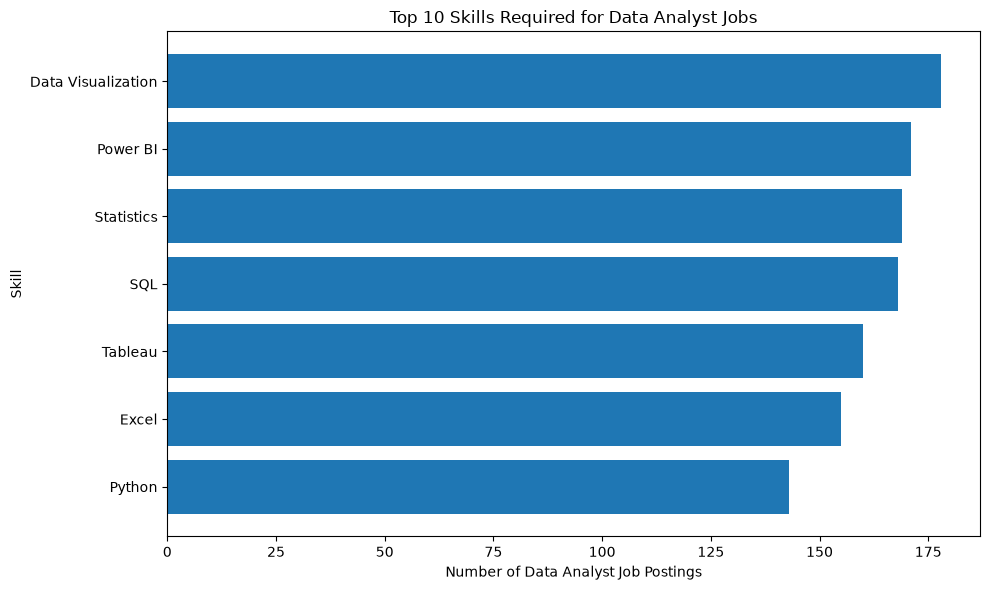

In [9]:

top_da_skills = da_skills.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_da_skills["Skill"][::-1],
    top_da_skills["Job_Postings"][::-1]
)
plt.xlabel("Number of Data Analyst Job Postings")
plt.ylabel("Skill")
plt.title("Top 10 Skills Required for Data Analyst Jobs")
plt.tight_layout()
plt.show()


## 8. Data Analyst Skills by Experience Level

In [10]:

rows = []

for experience in da["Experience_Level"].dropna().unique():
    subset = da[da["Experience_Level"] == experience]
    counter = Counter()

    for skills in subset["Skills_Required"].dropna():
        counter.update([
            s.strip() for s in str(skills).split(",")
            if s.strip()
        ])

    for skill, count in counter.items():
        rows.append([experience, skill, count])

da_skills_by_experience = pd.DataFrame(
    rows,
    columns=["Experience_Level", "Skill", "Job_Postings"]
).sort_values(
    ["Experience_Level", "Job_Postings"],
    ascending=[True, False]
)

display(da_skills_by_experience)


,Experience_Level,Skill,Job_Postings
0,Fresher (0-1 yr),SQL,34
2,Fresher (0-1 yr),Power BI,33
3,Fresher (0-1 yr),Statistics,31
6,Fresher (0-1 yr),Data Visualization,31
5,Fresher (0-1 yr),Python,30
1,Fresher (0-1 yr),Tableau,29
4,Fresher (0-1 yr),Excel,27
28,Junior (1-3 yrs),Power BI,35
29,Junior (1-3 yrs),SQL,34
30,Junior (1-3 yrs),Data Visualization,33


## 9. Data Analyst Competition

In [11]:

competition_summary = pd.DataFrame({
    "Metric": [
        "Average Applicants",
        "Median Applicants",
        "Average Openings",
        "Median Openings",
        "Average Applicants per Opening",
        "Maximum Applicants per Opening"
    ],
    "Value": [
        round(da["Applicants"].mean(), 2),
        round(da["Applicants"].median(), 2),
        round(da["Openings"].mean(), 2),
        round(da["Openings"].median(), 2),
        round(da["Applicants_per_Opening"].mean(), 2),
        round(da["Applicants_per_Opening"].max(), 2)
    ]
})

display(competition_summary)


,Metric,Value
0,Average Applicants,296.89
1,Median Applicants,189.50
2,Average Openings,3.67
3,Median Openings,2.00
4,Average Applicants per Opening,83.90
5,Maximum Applicants per Opening,119.00


## 10. Most Competitive Data Analyst Postings

In [12]:

most_competitive_da = (
    da[
        [
            "Job_ID", "Company", "City", "Experience_Level",
            "Work_Mode", "Openings", "Applicants",
            "Applicants_per_Opening", "Salary_LPA"
        ]
    ]
    .sort_values("Applicants_per_Opening", ascending=False)
    .head(15)
)

display(most_competitive_da)


,Job_ID,Company,City,Experience_Level,Work_Mode,Openings,Applicants,Applicants_per_Opening,Salary_LPA
3171,IND2028171,Flipkart,Delhi,Lead (10+ yrs),On-Site,2,238,119.0,62.7
2898,IND2027898,Microsoft,Remote,Lead (10+ yrs),On-Site,1,119,119.0,53.3
4407,IND2029407,DRDO,Pune,Mid (3-6 yrs),On-Site,5,595,119.0,9.7
1957,IND2026957,Khatabook,Pune,Fresher (0-1 yr),On-Site,5,594,118.8,5.6
3943,IND2028943,TCS,Ahmedabad,Junior (1-3 yrs),On-Site,3,354,118.0,9.2
2333,IND2027333,ONGC,Remote,Mid (3-6 yrs),Remote,2,236,118.0,3.3
4231,IND2029231,Fi Money,Remote,Junior (1-3 yrs),Remote,1,118,118.0,11.4
1749,IND2026749,Accenture,Mumbai,Senior (6-10 yrs),Hybrid,2,235,117.5,27.4
4138,IND2029138,Ola,Coimbatore,Junior (1-3 yrs),On-Site,1,117,117.0,13.5
4751,IND2029751,Dream11,Remote,Fresher (0-1 yr),Hybrid,2,233,116.5,7.1


## 11. Data Analyst Jobs by Industry

In [13]:

da_industry = (
    da["Industry"]
    .value_counts()
    .rename_axis("Industry")
    .reset_index(name="Job_Postings")
)

display(da_industry)


,Industry,Job_Postings
0,Information Technology,76
1,Banking & Finance,28
2,E-Commerce,25
3,FinTech,19
4,Manufacturing,19
5,EdTech,16
6,Consulting,15
7,HealthTech,14
8,Government/PSU,14
9,Media & Entertainment,9


## 12. Companies Hiring Data Analysts

In [14]:

da_companies = (
    da.groupby("Company")
    .agg(
        Job_Postings=("Job_ID", "count"),
        Total_Openings=("Openings", "sum"),
        Average_Salary_LPA=("Salary_LPA", "mean")
    )
    .reset_index()
    .sort_values(
        ["Total_Openings", "Job_Postings"],
        ascending=False
    )
)

display(da_companies.head(15))


,Company,Job_Postings,Total_Openings,Average_Salary_LPA
21,HCL Technologies,8,54,13.262500
30,MakeMyTrip,7,53,20.100000
26,Infosys,13,45,14.746154
29,Lenskart,10,37,23.390000
28,Leadsquared,4,37,23.150000
1,Amazon,8,34,22.037500
13,Deloitte,11,30,22.127273
47,Urban Company,3,28,13.266667
9,Cisco,6,27,14.866667
0,Accenture,9,26,26.322222


## 13. Education Requirements

In [15]:

da_education = (
    da["Education_Required"]
    .value_counts()
    .rename_axis("Education_Required")
    .reset_index(name="Job_Postings")
)

display(da_education)


,Education_Required,Job_Postings
0,B.Tech/B.E.,95
1,M.Tech/M.E.,39
2,MCA,37
3,BCA,26
4,MBA,21
5,B.Sc (CS/IT),19
6,B.Com + Certification,10
7,PhD,7


## 14. Data Analyst Salary by Work Mode

In [16]:

da_salary_work_mode = (
    da.groupby("Work_Mode")
    .agg(
        Job_Postings=("Job_ID", "count"),
        Average_Salary_LPA=("Salary_LPA", "mean"),
        Median_Salary_LPA=("Salary_LPA", "median")
    )
    .reset_index()
    .sort_values("Average_Salary_LPA", ascending=False)
)

display(da_salary_work_mode)


,Work_Mode,Job_Postings,Average_Salary_LPA,Median_Salary_LPA
1,On-Site,108,21.607407,16.5
2,Remote,65,21.472308,15.4
0,Hybrid,81,18.520988,15.0


## 15. Data Analyst Salary by City

In [17]:

da_salary_city = (
    da.groupby("City")
    .agg(
        Job_Postings=("Job_ID", "count"),
        Average_Salary_LPA=("Salary_LPA", "mean"),
        Median_Salary_LPA=("Salary_LPA", "median")
    )
    .reset_index()
)

# Keep cities with at least 5 Data Analyst postings
da_salary_city_filtered = (
    da_salary_city[da_salary_city["Job_Postings"] >= 5]
    .sort_values("Average_Salary_LPA", ascending=False)
)

display(da_salary_city_filtered)


,City,Job_Postings,Average_Salary_LPA,Median_Salary_LPA
1,Bangalore,13,24.123077,21.20
9,Jaipur,6,23.150000,16.65
4,Chennai,12,22.916667,10.30
7,Hyderabad,21,22.414286,19.30
16,Remote,101,21.535644,15.70
6,Delhi,17,20.676471,17.50
13,Mumbai,19,20.110526,16.00
15,Pune,23,19.343478,9.70
2,Bhubaneswar,7,18.314286,11.40
11,Kolkata,6,18.050000,19.70


## 16. Data Analyst Salary Anomalies

In [18]:

da_anomalies = da[
    da["Salary_Anomaly_Flag"].astype(str).str.lower() == "true"
].copy()

print("Flagged Data Analyst salary anomalies:", len(da_anomalies))

display(
    da_anomalies[
        [
            "Job_ID", "Job_Title", "Experience_Level",
            "Salary_LPA", "Company", "City"
        ]
    ]
)


Flagged Data Analyst salary anomalies: 1


,Job_ID,Job_Title,Experience_Level,Salary_LPA,Company,City
2815,IND2027815,Data Analyst,Mid (3-6 yrs),0.9,ISRO,Ahmedabad



## 17. Career-Oriented Skill Checklist

The following skills are evaluated against the Data Analyst postings in this dataset.

This is an analytical checklist, not a claim that every employer requires every skill.


In [19]:

target_skills = [
    "SQL",
    "Python",
    "Excel",
    "Power BI",
    "Tableau",
    "Statistics",
    "R",
    "PostgreSQL",
    "MySQL"
]

career_skill_rows = []

for skill in target_skills:
    count = da_skill_counter.get(skill, 0)
    career_skill_rows.append([
        skill,
        count,
        round(count / len(da) * 100, 2)
    ])

career_skill_df = pd.DataFrame(
    career_skill_rows,
    columns=["Skill", "Data_Analyst_Jobs", "Percentage_of_DA_Jobs"]
).sort_values("Data_Analyst_Jobs", ascending=False)

display(career_skill_df)


,Skill,Data_Analyst_Jobs,Percentage_of_DA_Jobs
3,Power BI,171,67.32
5,Statistics,169,66.54
0,SQL,168,66.14
4,Tableau,160,62.99
2,Excel,155,61.02
1,Python,143,56.30
6,R,0,0.00
7,PostgreSQL,0,0.00
8,MySQL,0,0.00


## 18. Export Step 6 Results

In [20]:

overview.to_csv("step6_da_overview.csv", index=False)
da_experience.to_csv("step6_da_experience.csv", index=False)
da_salary_experience.to_csv("step6_da_salary_by_experience.csv", index=False)
da_work_mode.to_csv("step6_da_work_mode.csv", index=False)
da_job_type.to_csv("step6_da_job_type.csv", index=False)
da_city.to_csv("step6_da_city.csv", index=False)
da_skills.to_csv("step6_da_skills.csv", index=False)
da_skills_by_experience.to_csv("step6_da_skills_by_experience.csv", index=False)
most_competitive_da.to_csv("step6_da_competitive_postings.csv", index=False)
da_industry.to_csv("step6_da_industry.csv", index=False)
da_companies.to_csv("step6_da_companies.csv", index=False)
da_education.to_csv("step6_da_education.csv", index=False)
da_salary_work_mode.to_csv("step6_da_salary_by_work_mode.csv", index=False)
da_salary_city_filtered.to_csv("step6_da_salary_by_city.csv", index=False)
career_skill_df.to_csv("step6_da_career_skill_checklist.csv", index=False)

print("Step 6 completed successfully.")
print("All Step 6 result CSV files were saved in the project folder.")


Step 6 completed successfully.
All Step 6 result CSV files were saved in the project folder.



# Step 6 Completion Note

This analysis gives the project a focused **Data Analyst career perspective** while keeping the main project broad enough to demonstrate general job-market analysis.

For the final portfolio version, this notebook will be cleaned of instructional text and presented as professional project documentation.

The final interview preparation will use the actual results produced here rather than memorized or invented findings.
